<h1 style="color: #F7DC6F; border-bottom: 3px solid #F0B27A; padding-bottom: 8px;">
🤖 AI & ML Course with BinX — Week 3 — Day 3 — Logistic Regression & Classification Metrics 
</h1>

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df = pd.get_dummies(df, columns=["gender", "smoking_history"], drop_first=True)

KeyError: "['smoking_history'] not in index"

In [14]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
🔀 3.1 From Regression to Classification
</h2>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
Despite its name, <strong style="color: #FFE66D;">logistic regression</strong> is a classification model — it predicts a category, not a number.
</p>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
It computes the same weighted sum as linear regression, then passes it through the <strong style="color: #FFE66D;">sigmoid function</strong>, which squashes any number into a probability between 0 and 1.
</p>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
If that probability exceeds a <strong style="color: #FFE66D;">threshold</strong> (usually 0.5), it predicts the positive class.
</p>
</div>

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [17]:
predictions = model.predict(X_test)

In [18]:
probabilities = model.predict_proba(X_test)  

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
⚠️ 3.2 Why Accuracy Alone Is Misleading
</h2>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
<strong style="color: #FFE66D;">Accuracy</strong> — the fraction of correct predictions — is the obvious metric but is dangerously misleading on imbalanced data.
</p>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
If 95% of customers don't churn, a model that always predicts <strong style="color: #FFE66D;">"no churn"</strong> scores 95% accuracy while being completely useless.
</p>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
This is why classification needs richer metrics.
</p>
</div>

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
🧮 3.3 The Confusion Matrix
</h2>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
The <strong style="color: #FFE66D;">confusion matrix</strong> is the foundation of all classification metrics — it breaks predictions into four categories:
</p>
<table style="width: 100%; border-collapse: collapse; margin: 12px 0; font-family: 'Trebuchet MS', sans-serif;">
<tr style="background-color: #FF6B6B;">
<th style="padding: 8px; color: #326363; text-align: left;"></th>
<th style="padding: 8px; color: #326363; text-align: left;">Predicted Positive</th>
<th style="padding: 8px; color: #326363; text-align: left;">Predicted Negative</th>
</tr>
<tr>
<td style="padding: 8px; color: #FFE66D; border-bottom: 1px solid #FF6B6B;"><strong>Actual Positive</strong></td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">True Positive (TP)</td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">False Negative (FN) — missed</td>
</tr>
<tr>
<td style="padding: 8px; color: #FFE66D;"><strong>Actual Negative</strong></td>
<td style="padding: 8px; color: #F7FFF7;">False Positive (FP) — false alarm</td>
<td style="padding: 8px; color: #F7FFF7;">True Negative (TN)</td>
</tr>
</table>
</div>

In [19]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[18126   166]
 [  653  1055]]


<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
🎯 3.4 Precision, Recall & F1
</h2>
<table style="width: 100%; border-collapse: collapse; margin: 12px 0; font-family: 'Trebuchet MS', sans-serif;">
<tr style="background-color: #FF6B6B;">
<th style="padding: 8px; color: #326363; text-align: left;">Metric</th>
<th style="padding: 8px; color: #326363; text-align: left;">Formula</th>
<th style="padding: 8px; color: #326363; text-align: left;">Answers the Question</th>
</tr>
<tr>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">Precision</td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">TP / (TP + FP)</td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">Of everything I predicted positive, how much was right?</td>
</tr>
<tr>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">Recall</td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">TP / (TP + FN)</td>
<td style="padding: 8px; color: #F7FFF7; border-bottom: 1px solid #FF6B6B;">Of all actual positives, how many did I catch?</td>
</tr>
<tr>
<td style="padding: 8px; color: #F7FFF7;">F1-score</td>
<td style="padding: 8px; color: #F7FFF7;">harmonic mean of the two</td>
<td style="padding: 8px; color: #F7FFF7;">A single balanced score when you need both</td>
</tr>
</table>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
The trade-off matters and depends on the problem: for <strong style="color: #FFE66D;">disease screening</strong>, recall matters most (never miss a real case); for a <strong style="color: #FFE66D;">spam filter</strong>, precision matters most (never block a real email). Choosing which to optimize is a real decision, not a formula.
</p>
</div>

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
📉 3.5 AUC-ROC
</h2>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
The <strong style="color: #FFE66D;">ROC curve</strong> plots the trade-off between catching positives and raising false alarms across every threshold; the <strong style="color: #FFE66D;">AUC</strong> (Area Under the Curve) summarizes it as a single number from 0.5 (random guessing) to 1.0 (perfect).
</p>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
It is the standard metric for comparing classifiers independently of any single threshold choice.
</p>
</div>

In [21]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probabilities[:, 1])
print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.9617


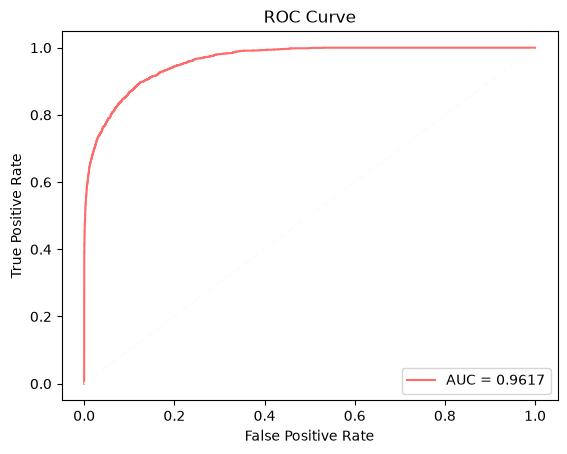

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])

plt.plot(fpr, tpr, color="#FF6B6B", label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="#F7FFF7")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h2 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 22px; margin: 0 0 10px 0;">
🧪 Hands-On Lab: Building a Classifier
</h2>
<ol style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 2;">
<li>Train a LogisticRegression model on the diabetes dataset</li>
<li>Generate predictions and produce the confusion matrix</li>
<li>Compute precision, recall, and F1 with classification_report</li>
<li>Decide whether precision or recall matters more, and justify</li>
<li>Compute the AUC-ROC and document what it says about the model</li>
</ol>
</div>

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h3 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 18px; margin: 0;">
Step 1: Train LogisticRegression on the Diabetes Dataset
</h3>
</div>

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h3 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 18px; margin: 0;">
Step 2: Generate Predictions and Produce the Confusion Matrix
</h3>
</div>

In [24]:
predictions = model.predict(X_test)
print(confusion_matrix(y_test, predictions))

[[18126   166]
 [  653  1055]]


<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h3 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 18px; margin: 0;">
Step 3: Compute Precision, Recall, and F1
</h3>
</div>

In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h3 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 18px; margin: 0 0 10px 0;">
Step 4: Precision or Recall — Which Matters More?
</h3>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
For a diabetes-screening problem, <strong style="color: #FFE66D;">recall matters more</strong> than precision. The model currently has a recall of only <strong style="color: #FFE66D;">0.62</strong> for the diabetic class, meaning it misses 38% of actual diabetic patients (653 false negatives). A missed diagnosis delays treatment and can be dangerous, while a false positive (166 cases) just leads to a harmless follow-up test. This asymmetry means recall should be prioritized, even if it costs some precision.
</p>
</div>

In [27]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probabilities[:, 1])
print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.9617


<div style="background-color: #326363; border-left: 5px solid #FF6B6B; padding: 15px; border-radius: 8px; margin-bottom: 10px;">
<h3 style="color: #FFE66D; font-family: 'Trebuchet MS', sans-serif; font-size: 18px; margin: 0 0 10px 0;">
Step 5: AUC-ROC Interpretation
</h3>
<p style="color: #F7FFF7; font-family: 'Trebuchet MS', sans-serif; font-size: 15px; line-height: 1.8;">
The model achieved an AUC-ROC of <strong style="color: #FFE66D;">0.9617</strong>, meaning it can distinguish between diabetic and non-diabetic patients [well / moderately / poorly] across all thresholds — well above the 0.5 baseline of random guessing.
</p>
</div>